In [1]:
import os
import re
import polars as pl
import matplotlib.pyplot as plt
import seaborn as sns
import math

In [2]:
input_dir = '../dataset/dataset_final/results_analyzed'

df_dict = {}

for df_name in os.listdir(input_dir):
    if 'Aria' not in df_name:
        model = re.sub('_analyzed.parquet','',df_name)
        df_dict[model] = pl.read_parquet(f'{input_dir}/{df_name}')

df_dict_standard = {}
filter = ['16f','32f','hints']
for name in df_dict.keys():
    use = True
    for el in filter:
        if el in name:
            use = False
    if use:
        df_dict_standard[name] = df_dict[name]


def filtering_df_dict(local_filter, df_dict):
    df_dict_buffer = {}
    buffer_name = []
    for name in df_dict.keys():
        for el in local_filter:
            if el in name:
                buffer_name.append(name)

    for name in df_dict.keys():
        for el in buffer_name:
            if name in el and name !=el:
                buffer_name.append(name)

    for name in buffer_name:
        df_dict_buffer[name] = df_dict[name]
    return df_dict_buffer

filter_frames = ['16f','32f']
df_dict_frames = filtering_df_dict(filter_frames, df_dict)

filter_hints = ["hints"]
df_dict_hints = filtering_df_dict(filter_hints, df_dict)

# Standard analysis

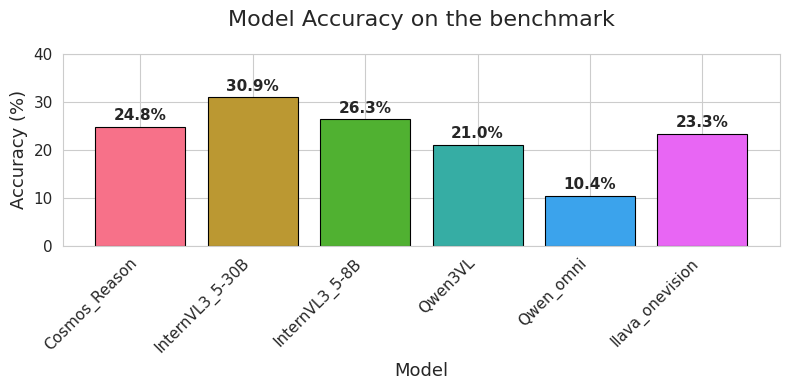

In [11]:
# -----------------------------
# 2. Compute accuracy per model
# -----------------------------
accuracies = []
model_names = []

# Sort models alphabetically for consistent, readable order
for model in sorted(df_dict_standard.keys()):
    df = df_dict_standard[model]
    
    # Safety check: ensure 'correct' column exists
    if 'correct' not in df.columns:
        raise ValueError(f"Column 'correct' missing in dataframe for model '{model}'")
    
    acc = df['correct'].mean()          # mean of boolean → accuracy
    accuracies.append(acc)
    model_names.append(model)

# Convert to percentages for display
acc_percent = [acc * 100 for acc in accuracies]

# -----------------------------
# 3. Create the bar plot
# -----------------------------
plt.figure(figsize=(max(8, len(model_names) * 1.2), int(7*0.6)))
sns.set_style("whitegrid")
colors = sns.color_palette("husl", len(model_names))

bars = plt.bar(model_names, acc_percent, color=colors, edgecolor='black', linewidth=0.8)

# Add percentage labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,                                      # slightly above the bar
        f'{height:.1f}%',                                 # one decimal place
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

# Aesthetics
plt.title('Model Accuracy on the benchmark', fontsize=16, pad=20)
plt.ylabel('Accuracy (%)', fontsize=13)
plt.xlabel('Model', fontsize=13)
plt.ylim(0, 40)                                        # accuracy scale
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Tight layout to prevent label cutoff
plt.tight_layout()

# -----------------------------
# 4. Save and/or show
# -----------------------------
output_path = '../report/figures/overall_accuracy.pdf'
plt.savefig(output_path, bbox_inches='tight')
#print(f"Plot saved to {output_path}")

plt.show()

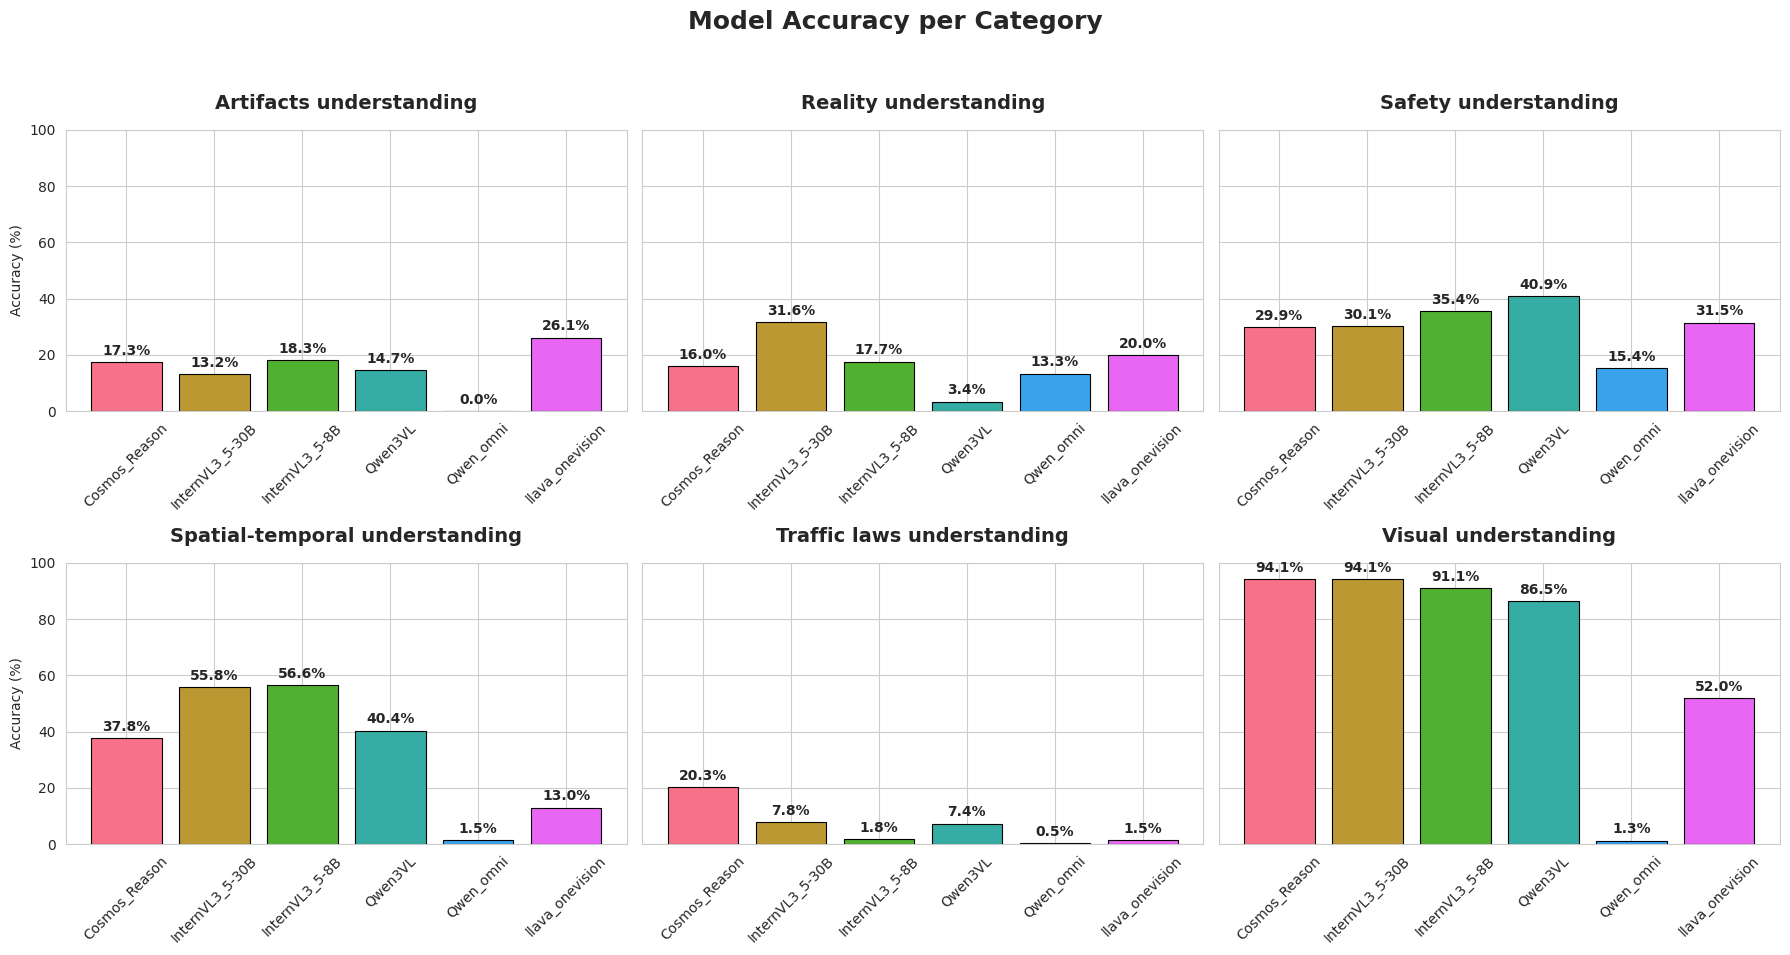

In [28]:
# Add model name column and concatenate everything
combined_df = (
    pl.concat(
        [df.with_columns(pl.lit(model).alias("model_name")) for model, df in df_dict_standard.items()]
    )
    .with_columns(pl.col("correct").cast(pl.Boolean))
)

# -----------------------------
# 2. Compute accuracy per category and per model (pure Polars)
# -----------------------------
accuracy_df = (
    combined_df
    .group_by(["category", "model_name"])
    .agg(pl.mean("correct").alias("accuracy"))
    .sort(["category", "model_name"])
)

# Get ordered lists
categories = accuracy_df["category"].unique().sort().to_list()
models     = accuracy_df["model_name"].unique().sort().to_list()

# -----------------------------
# 3. 3×2 subplot grid – 100% Matplotlib/Seaborn (no pandas needed)
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.flatten()

sns.set_style("whitegrid")
palette = sns.color_palette("husl", len(models))

for idx, category in enumerate(categories):
    ax = axes[idx]
    
    # Filter data for this category
    data = accuracy_df.filter(pl.col("category") == category)
    
    # Create bar plot directly from Polars (via lists for simplicity and speed)
    acc_values = data["accuracy"].to_list()
    model_order = data["model_name"].to_list()
    
    bars = ax.bar(model_order, [a * 100 for a in acc_values],  # to percentage
                  color=palette, edgecolor='black', linewidth=0.8)
    
    ax.set_title(category, fontsize=14, fontweight='bold', pad=15)
    ax.set_ylim(0, 100)
    ax.set_ylabel("Accuracy (%)" if idx % 3 == 0 else "")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)
    
    # Percentage labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 1.5,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Remove empty subplots if fewer than 6 categories
for idx in range(len(categories), 6):
    fig.delaxes(axes[idx])

# Global title and legend
fig.suptitle('Model Accuracy per Category', fontsize=18, fontweight='bold', y=0.98)

# Single legend outside the plots
#handles = [plt.Rectangle((0,0),1,1, color=palette[i]) for i in range(len(models))]
#fig.legend(handles, models, title="Model", loc='upper right', bbox_to_anchor=(0.98, 0.88))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save and show
output_path = '../report/figures/overall_accuracy_per_category.pdf'
plt.savefig(output_path, bbox_inches='tight')
#print(f"Plot saved to {output_path}")
plt.show()

# Ablation
## Number of frames

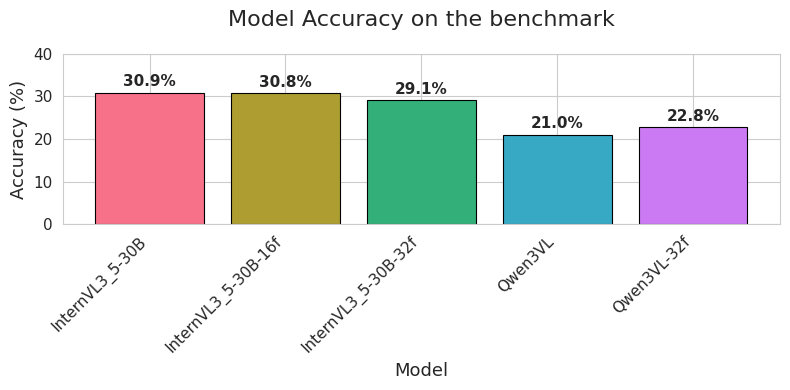

In [29]:
# -----------------------------
# 2. Compute accuracy per model
# -----------------------------
accuracies = []
model_names = []

# Sort models alphabetically for consistent, readable order
for model in sorted(df_dict_frames.keys()):
    df = df_dict_frames[model]
    
    # Safety check: ensure 'correct' column exists
    if 'correct' not in df.columns:
        raise ValueError(f"Column 'correct' missing in dataframe for model '{model}'")
    
    acc = df['correct'].mean()          # mean of boolean → accuracy
    accuracies.append(acc)
    model_names.append(model)

# Convert to percentages for display
acc_percent = [acc * 100 for acc in accuracies]

# -----------------------------
# 3. Create the bar plot
# -----------------------------
plt.figure(figsize=(max(8, len(model_names) * 1.2), int(7*0.6)))
sns.set_style("whitegrid")
colors = sns.color_palette("husl", len(model_names))

bars = plt.bar(model_names, acc_percent, color=colors, edgecolor='black', linewidth=0.8)

# Add percentage labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,                                      # slightly above the bar
        f'{height:.1f}%',                                 # one decimal place
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

# Aesthetics
plt.title('Model Accuracy on the benchmark', fontsize=16, pad=20)
plt.ylabel('Accuracy (%)', fontsize=13)
plt.xlabel('Model', fontsize=13)
plt.ylim(0, 40)                                        # accuracy scale
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Tight layout to prevent label cutoff
plt.tight_layout()

# -----------------------------
# 4. Save and/or show
# -----------------------------
output_path = '../report/figures/frame_ablation_accuracy.pdf'
plt.savefig(output_path, bbox_inches='tight')
#print(f"Plot saved to {output_path}")

plt.show()

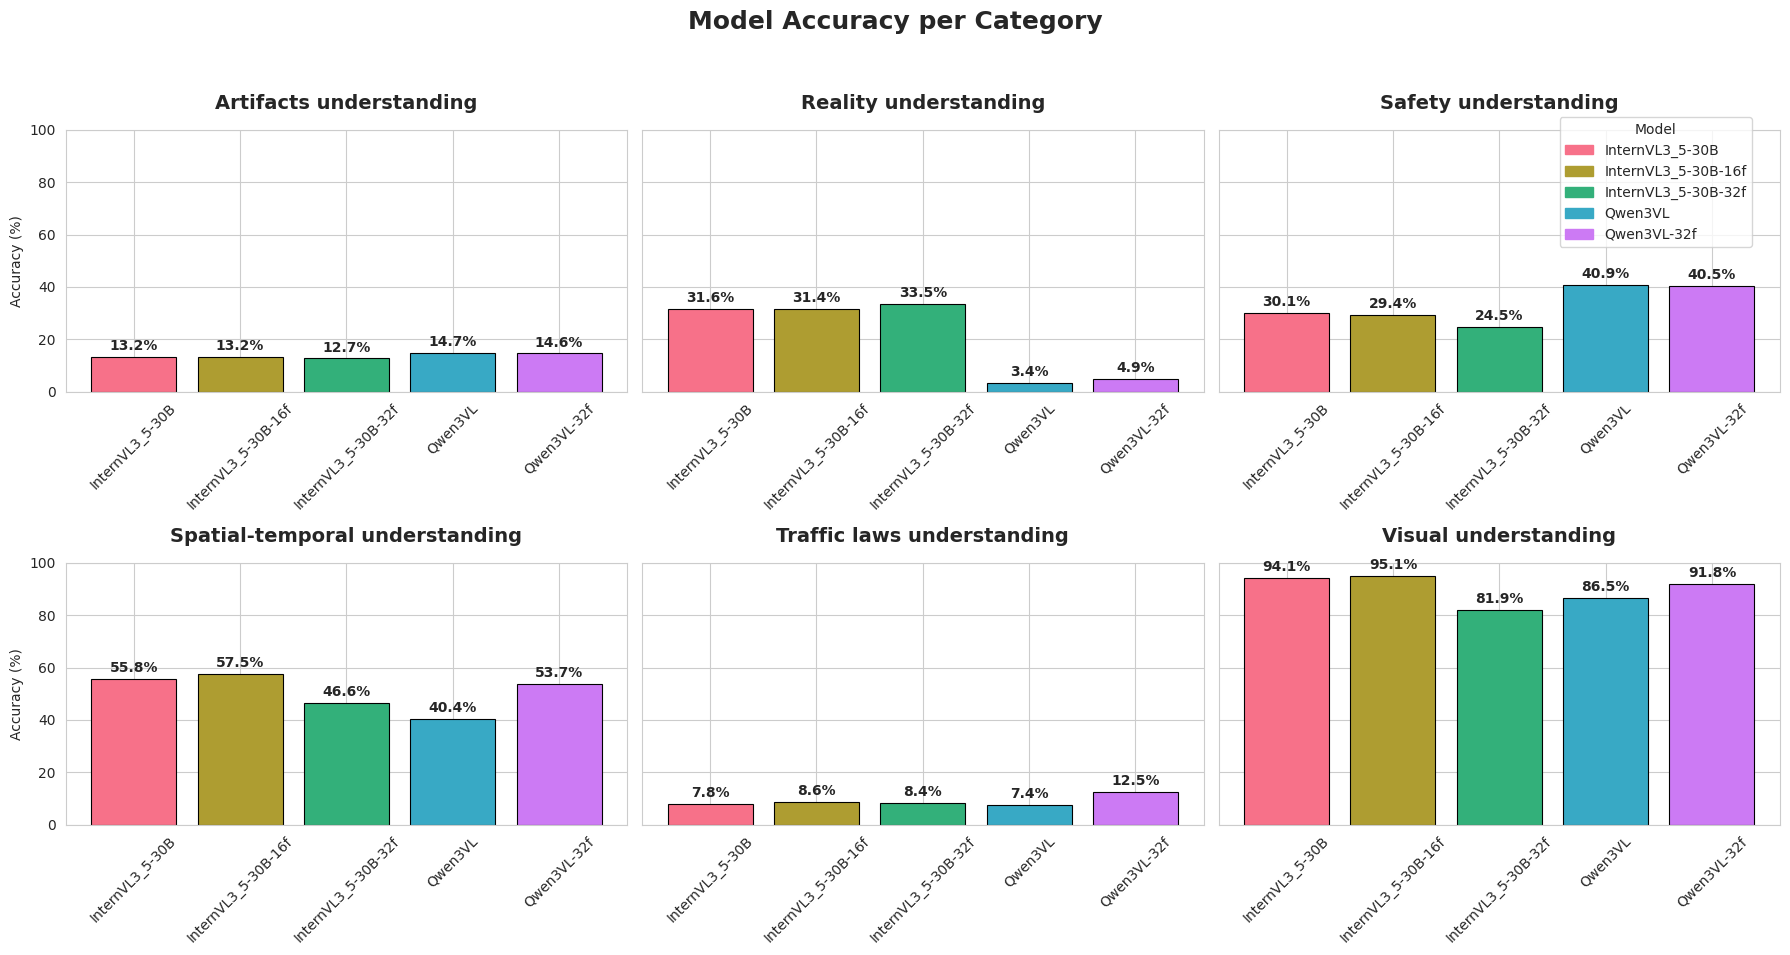

In [30]:
# Add model name column and concatenate everything
combined_df = (
    pl.concat(
        [df.with_columns(pl.lit(model).alias("model_name")) for model, df in df_dict_frames.items()]
    )
    .with_columns(pl.col("correct").cast(pl.Boolean))
)

# -----------------------------
# 2. Compute accuracy per category and per model (pure Polars)
# -----------------------------
accuracy_df = (
    combined_df
    .group_by(["category", "model_name"])
    .agg(pl.mean("correct").alias("accuracy"))
    .sort(["category", "model_name"])
)

# Get ordered lists
categories = accuracy_df["category"].unique().sort().to_list()
models     = accuracy_df["model_name"].unique().sort().to_list()

# -----------------------------
# 3. 3×2 subplot grid – 100% Matplotlib/Seaborn (no pandas needed)
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.flatten()

sns.set_style("whitegrid")
palette = sns.color_palette("husl", len(models))

for idx, category in enumerate(categories):
    ax = axes[idx]
    
    # Filter data for this category
    data = accuracy_df.filter(pl.col("category") == category)
    
    # Create bar plot directly from Polars (via lists for simplicity and speed)
    acc_values = data["accuracy"].to_list()
    model_order = data["model_name"].to_list()
    
    bars = ax.bar(model_order, [a * 100 for a in acc_values],  # to percentage
                  color=palette, edgecolor='black', linewidth=0.8)
    
    ax.set_title(category, fontsize=14, fontweight='bold', pad=15)
    ax.set_ylim(0, 100)
    ax.set_ylabel("Accuracy (%)" if idx % 3 == 0 else "")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)
    
    # Percentage labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 1.5,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Remove empty subplots if fewer than 6 categories
for idx in range(len(categories), 6):
    fig.delaxes(axes[idx])

# Global title and legend
fig.suptitle('Model Accuracy per Category', fontsize=18, fontweight='bold', y=0.98)

# Single legend outside the plots
handles = [plt.Rectangle((0,0),1,1, color=palette[i]) for i in range(len(models))]
fig.legend(handles, models, title="Model", loc='upper right', bbox_to_anchor=(0.98, 0.88))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save and show
output_path = '../report/figures/frame_ablation_accuracy_per_category.pdf'
plt.savefig(output_path, bbox_inches='tight')
#print(f"Plot saved to {output_path}")
plt.show()

## Chain of Thought

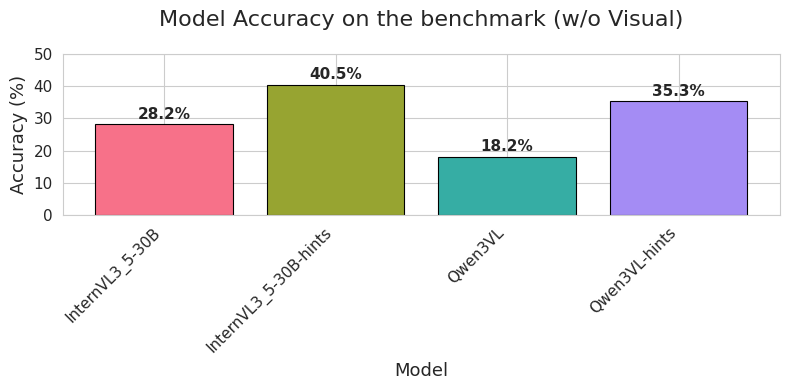

In [31]:
# -----------------------------
# 2. Compute accuracy per model
# -----------------------------
accuracies = []
model_names = []

for model in sorted(df_dict_hints.keys()):
    df = df_dict_hints[model]
    
    if 'correct' not in df.columns:
        raise ValueError(f"Column 'correct' missing in dataframe for model '{model}'")
    
    df_filtered = df.clone()
    
    # Exclude "Visual understanding" category when the column exists
    if 'category' in df.columns:
        df_filtered = df_filtered.filter(pl.col('category') != 'Visual understanding')
    
    acc = df_filtered['correct'].mean() if len(df_filtered) > 0 else float('nan')
    
    accuracies.append(acc)
    model_names.append(model)

# Convert to percentages (treat NaN as 0% for plotting, or keep NaN if you prefer no bar)
acc_percent = [acc * 100 if not (isinstance(acc, float) and math.isnan(acc)) else 0 
               for acc in accuracies]

# -----------------------------
# 3. Create the bar plot
# -----------------------------
plt.figure(figsize=(max(8, len(model_names) * 1.2), int(7*0.7)))
sns.set_style("whitegrid")
colors = sns.color_palette("husl", len(model_names))

bars = plt.bar(model_names, acc_percent, color=colors, edgecolor='black', linewidth=0.8)

# Add percentage labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,                                      # slightly above the bar
        f'{height:.1f}%',                                 # one decimal place
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

# Aesthetics
plt.title('Model Accuracy on the benchmark (w/o Visual)', fontsize=16, pad=20)
plt.ylabel('Accuracy (%)', fontsize=13)
plt.xlabel('Model', fontsize=13)
plt.ylim(0, 50)                                        # accuracy scale
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Tight layout to prevent label cutoff
plt.tight_layout()

# -----------------------------
# 4. Save and/or show
# -----------------------------
output_path = '../report/figures/COT_ablation_accuracy.pdf'
plt.savefig(output_path, bbox_inches='tight')
#print(f"Plot saved to {output_path}")

plt.show()

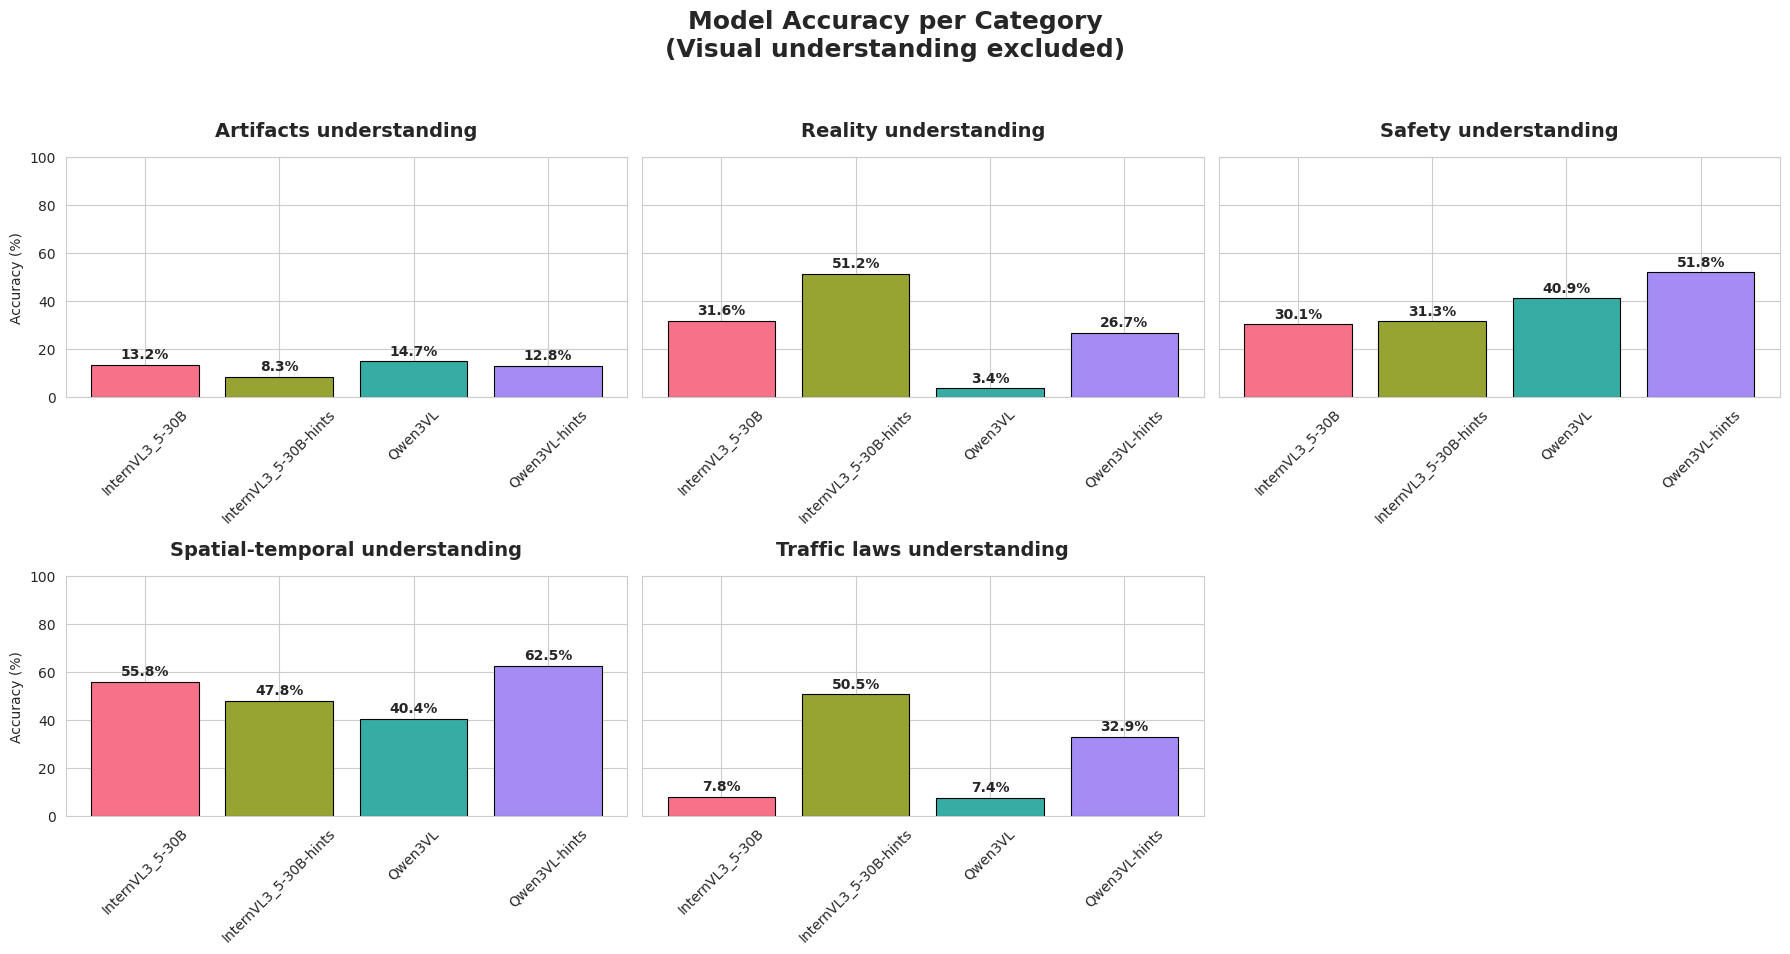

In [32]:
# Add model name column and concatenate everything
combined_df = (
    pl.concat(
        [df.with_columns(pl.lit(model).alias("model_name")) for model, df in df_dict_hints.items()]
    )
    .with_columns(pl.col("correct").cast(pl.Boolean))
    # Exclude the "Visual understanding" category globally for this plot
    .filter(pl.col("category") != "Visual understanding")
)

# -----------------------------
# 2. Compute accuracy per category and per model (pure Polars)
# -----------------------------
accuracy_df = (
    combined_df
    .group_by(["category", "model_name"])
    .agg(pl.mean("correct").alias("accuracy"))
    .sort(["category", "model_name"])
)

# Get ordered lists (now without "Visual understanding")
categories = accuracy_df["category"].unique().sort().to_list()
models = accuracy_df["model_name"].unique().sort().to_list()

# -----------------------------
# 3. Subplot grid – automatically adapts to number of remaining categories
# -----------------------------
n_categories = len(categories)
n_cols = 3
n_rows = (n_categories + n_cols - 1) // n_cols  # Ceiling division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 5 * n_rows), sharey=True)
axes = axes.flatten() if n_categories > 1 else [axes]  # Handle single subplot case

sns.set_style("whitegrid")
palette = sns.color_palette("husl", len(models))

for idx, category in enumerate(categories):
    ax = axes[idx]
    data = accuracy_df.filter(pl.col("category") == category)
    
    acc_values = data["accuracy"].to_list()
    model_order = data["model_name"].to_list()
    
    bars = ax.bar(model_order, [a * 100 for a in acc_values],
                  color=palette, edgecolor='black', linewidth=0.8)
    
    ax.set_title(category, fontsize=14, fontweight='bold', pad=15)
    ax.set_ylim(0, 100)
    ax.set_ylabel("Accuracy (%)" if idx % n_cols == 0 else "")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)
    
    # Add percentage labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 1.5,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Remove unused subplots
for idx in range(n_categories, len(axes)):
    fig.delaxes(axes[idx])

# Global title and shared legend
fig.suptitle('Model Accuracy per Category\n(Visual understanding excluded)', 
             fontsize=18, fontweight='bold', y=0.98)

#handles = [plt.Rectangle((0,0),1,1, color=palette[i]) for i in range(len(models))]
#fig.legend(handles, models, title="Model", loc='upper right', bbox_to_anchor=(0.98, 0.88))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])
# -----------------------------
# 4. Save and/or show
# -----------------------------
output_path = '../report/figures/COT_ablation_accuracy_per_category.pdf'
plt.savefig(output_path, bbox_inches='tight')

plt.show()

## Agentic AI

In [37]:
input_dir = '../dataset/dataset_final/results_analyzed_agent'

df_dict_agent = {}

for df_name in os.listdir(input_dir):
    model = re.sub('_analyzed.parquet','',df_name)
    df_dict_agent[model] = pl.read_parquet(f'{input_dir}/{df_name}')

col = df_dict_agent['Qwen3VL_Agent'].drop_in_place("history")
del col

df_dict_agent['InternVL3_5-30B'] = df_dict_standard['InternVL3_5-30B']
df_dict_agent['Qwen3VL-hints'] = df_dict_hints['Qwen3VL-hints']

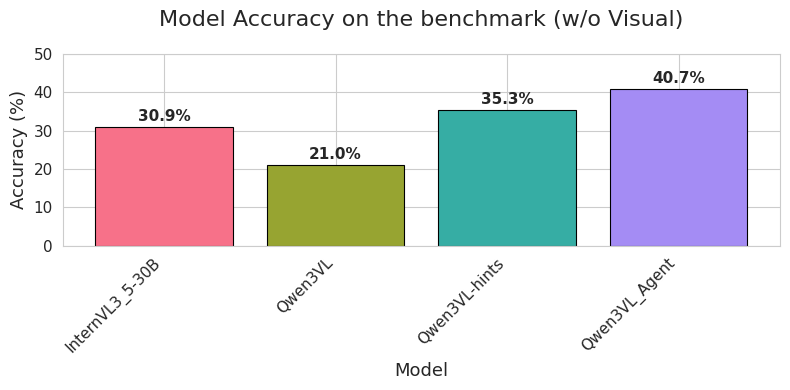

In [41]:
# -----------------------------
# 2. Compute accuracy per model
# -----------------------------
accuracies = []
model_names = []

for model in sorted(df_dict_agent.keys()):
    df = df_dict_agent[model]
    
    if 'correct' not in df.columns:
        raise ValueError(f"Column 'correct' missing in dataframe for model '{model}'")
    
    df_filtered = df.clone()
    
    if 'Agent' not in model:
        acc = df_filtered['correct'].mean()
    else:
        acc = df_filtered['correct'].sum()/len(df_dict_agent['Qwen3VL'])
    
    accuracies.append(acc)
    model_names.append(model)

# Convert to percentages (treat NaN as 0% for plotting, or keep NaN if you prefer no bar)
acc_percent = [acc * 100 if not (isinstance(acc, float) and math.isnan(acc)) else 0 
               for acc in accuracies]

# -----------------------------
# 3. Create the bar plot
# -----------------------------
plt.figure(figsize=(max(8, len(model_names) * 1.2), int(7*0.6)))
sns.set_style("whitegrid")
colors = sns.color_palette("husl", len(model_names))

bars = plt.bar(model_names, acc_percent, color=colors, edgecolor='black', linewidth=0.8)

# Add percentage labels on top of each bar
for bar in bars:
    height = bar.get_height()
    plt.text(
        bar.get_x() + bar.get_width() / 2,
        height + 0.8,                                      # slightly above the bar
        f'{height:.1f}%',                                 # one decimal place
        ha='center', va='bottom', fontsize=11, fontweight='bold'
    )

# Aesthetics
plt.title('Model Accuracy on the benchmark (w/o Visual)', fontsize=16, pad=20)
plt.ylabel('Accuracy (%)', fontsize=13)
plt.xlabel('Model', fontsize=13)
plt.ylim(0, 50)                                        # accuracy scale
plt.xticks(rotation=45, ha='right', fontsize=11)
plt.yticks(fontsize=11)

# Tight layout to prevent label cutoff
plt.tight_layout()

# -----------------------------
# 4. Save and/or show
# -----------------------------
output_path = '../report/figures/agent_accuracy.pdf'
plt.savefig(output_path, bbox_inches='tight')
#print(f"Plot saved to {output_path}")

plt.show()

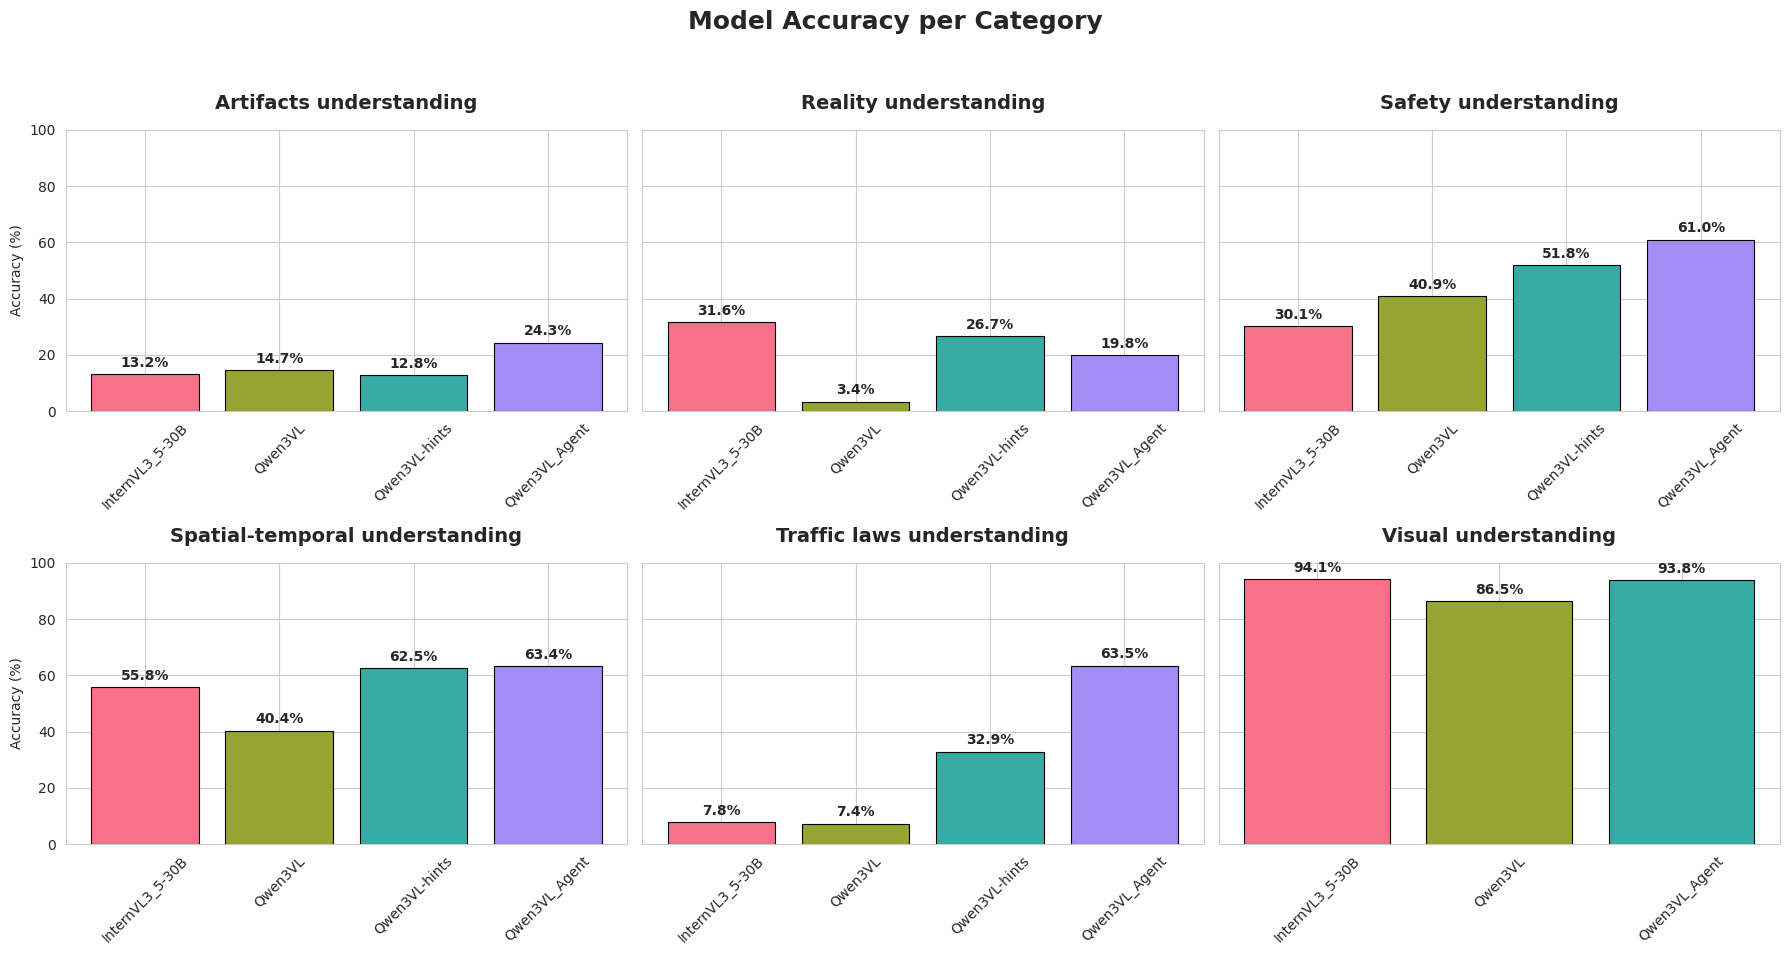

In [42]:
# Add model name column and concatenate everything
combined_df = (
    pl.concat(
        [df.with_columns(pl.lit(model).alias("model_name")) for model, df in df_dict_agent.items()]
    )
    .with_columns(pl.col("correct").cast(pl.Boolean))
)

# -----------------------------
# 2. Compute accuracy per category and per model (pure Polars)
# -----------------------------
accuracy_df = (
    combined_df
    .group_by(["category", "model_name"])
    .agg(pl.mean("correct").alias("accuracy"))
    .sort(["category", "model_name"])
)

# Get ordered lists
categories = accuracy_df["category"].unique().sort().to_list()
models     = accuracy_df["model_name"].unique().sort().to_list()

# -----------------------------
# 3. 3×2 subplot grid – 100% Matplotlib/Seaborn (no pandas needed)
# -----------------------------
fig, axes = plt.subplots(2, 3, figsize=(18, 10), sharey=True)
axes = axes.flatten()

sns.set_style("whitegrid")
palette = sns.color_palette("husl", len(models))

for idx, category in enumerate(categories):
    ax = axes[idx]
    
    # Filter data for this category
    data = accuracy_df.filter(pl.col("category") == category)
    
    # Create bar plot directly from Polars (via lists for simplicity and speed)
    acc_values = data["accuracy"].to_list()
    model_order = data["model_name"].to_list()
    
    bars = ax.bar(model_order, [a * 100 for a in acc_values],  # to percentage
                  color=palette, edgecolor='black', linewidth=0.8)
    
    ax.set_title(category, fontsize=14, fontweight='bold', pad=15)
    ax.set_ylim(0, 100)
    ax.set_ylabel("Accuracy (%)" if idx % 3 == 0 else "")
    ax.set_xlabel("")
    ax.tick_params(axis='x', rotation=45)
    
    # Percentage labels on top of bars
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, height + 1.5,
                f'{height:.1f}%',
                ha='center', va='bottom', fontsize=10, fontweight='bold')

# Remove empty subplots if fewer than 6 categories
for idx in range(len(categories), 6):
    fig.delaxes(axes[idx])

# Global title and legend
fig.suptitle('Model Accuracy per Category', fontsize=18, fontweight='bold', y=0.98)

# Single legend outside the plots
#handles = [plt.Rectangle((0,0),1,1, color=palette[i]) for i in range(len(models))]
#fig.legend(handles, models, title="Model", loc='upper right', bbox_to_anchor=(0.98, 0.88))

plt.tight_layout(rect=[0, 0.03, 1, 0.95])

# Save and show
output_path = '../report/figures/agent_accuracy_per_category.pdf'
plt.savefig(output_path, dpi=300, bbox_inches='tight')
#print(f"Plot saved to {output_path}")
plt.show()